# V3 moneyness performance — 1.5-year fixed calibration

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V3_1p5y_fixed_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, Modified GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT, AMZN (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 802` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
1.5-year lookback, `none` recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 10,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_fixed_empirical_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2008-2009,18,43,80,43,16,200
2013-2014,0,5,192,3,0,200
2018-2019,0,4,191,7,0,202
2019-2020,0,6,189,5,0,200
All,18,58,652,58,16,802


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 18  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,18,34.14,1.2323,-0.4208,-3.15,18.8%,4
Modified GBM,18,33.14,1.2868,-0.7616,-11.27,19.8%,3
GARCH,18,39.30,1.2347,+0.0342,+10.69,14.5%,6
Heston,18,30.93,1.2079,-0.6936,-10.00,20.2%,2
Merton,18,35.23,1.2558,-0.4101,-3.30,15.8%,5
GARCH–Merton,18,53.89,1.4954,+0.6023,+25.64,14.1%,7
Heston–Merton,18,30.36,1.2048,-0.7394,-11.47,14.2%,1


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 58  ·  **BEST = Modified GBM**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,58,43.05,1.2320,-0.0840,+5.78,21.7%,5
Modified GBM,58,40.29,1.1889,-0.3358,+0.62,22.7%,1
GARCH,58,47.98,1.2857,+0.2906,+19.83,16.8%,6
Heston,58,41.67,1.1988,-0.0490,+6.77,21.3%,3
Merton,58,42.06,1.2328,-0.1106,+4.24,18.4%,4
GARCH–Merton,58,59.12,1.4946,+0.6796,+31.70,16.0%,7
Heston–Merton,58,40.93,1.1691,-0.1629,+4.60,17.9%,2


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 652  ·  **BEST = Merton**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,652,41.64,4.4486,+0.8708,+14.16,24.0%,3
Modified GBM,652,41.49,4.5182,+1.1699,+12.76,24.5%,2
GARCH,652,42.22,4.2223,+0.1817,+15.35,20.0%,4
Heston,652,52.44,5.5730,+2.6251,+28.83,23.8%,6
Merton,652,39.75,4.4134,+0.4761,+11.64,19.8%,1
GARCH–Merton,652,51.30,4.6488,+1.5259,+26.29,18.4%,5
Heston–Merton,652,52.68,5.5107,+3.5252,+27.90,20.3%,7


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 58  ·  **BEST = Merton**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,58,28.03,1.0069,-0.4877,-10.20,27.6%,2
Modified GBM,58,28.24,0.9858,-0.6538,-12.90,28.7%,4
GARCH,58,29.40,1.0073,-0.0933,+3.31,21.3%,6
Heston,58,29.04,1.0765,-0.2625,-5.17,27.8%,5
Merton,58,27.87,1.0005,-0.5357,-11.59,23.8%,1
GARCH–Merton,58,32.59,1.1342,+0.2247,+10.23,20.0%,7
Heston–Merton,58,28.19,1.0084,-0.3951,-7.36,23.7%,3


### Table M5. DITM  ·  m > 1.02  ·  n = 16  ·  **BEST = Heston–Merton**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,16,25.04,1.2933,-0.3293,-3.90,29.2%,5
Modified GBM,16,24.31,1.2710,-0.6582,-9.33,30.8%,3
GARCH,16,30.03,1.3144,+0.2288,+9.44,18.9%,6
Heston,16,23.87,1.2470,-0.4516,-4.94,30.6%,2
Merton,16,24.89,1.2947,-0.3876,-5.13,24.9%,4
GARCH–Merton,16,37.87,1.4533,+0.7255,+18.85,20.8%,7
Heston–Merton,16,23.21,1.2080,-0.6335,-8.28,21.7%,1


### Figure M1 — Model × Moneyness RMSE% heatmap


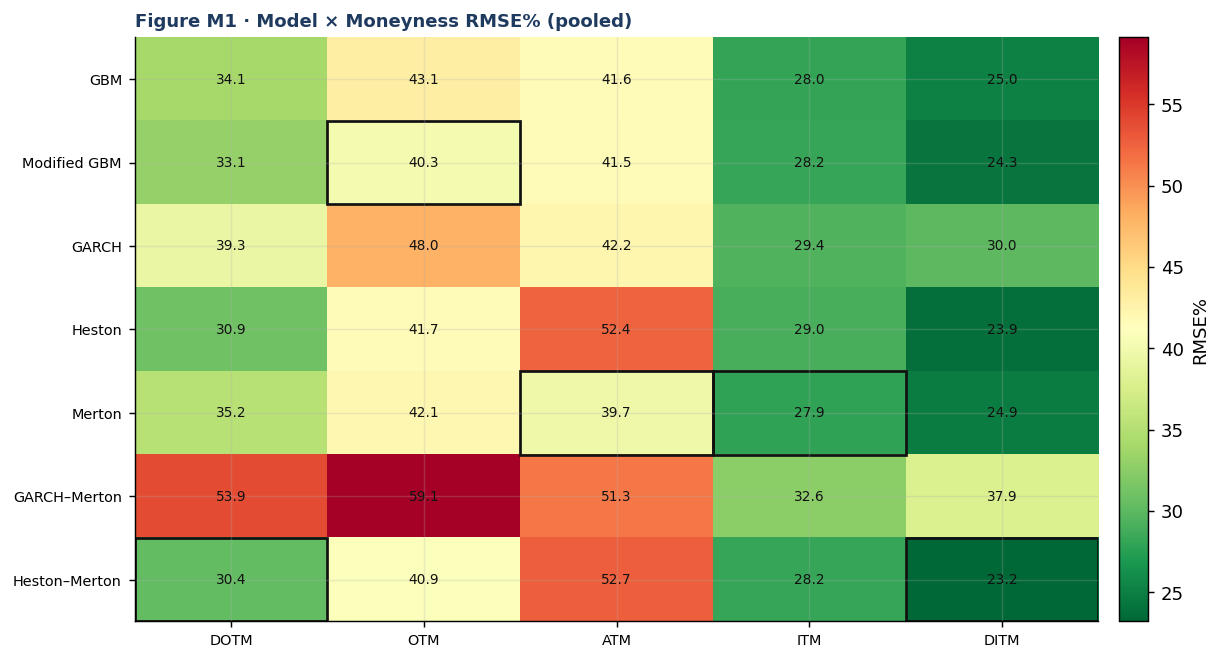

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


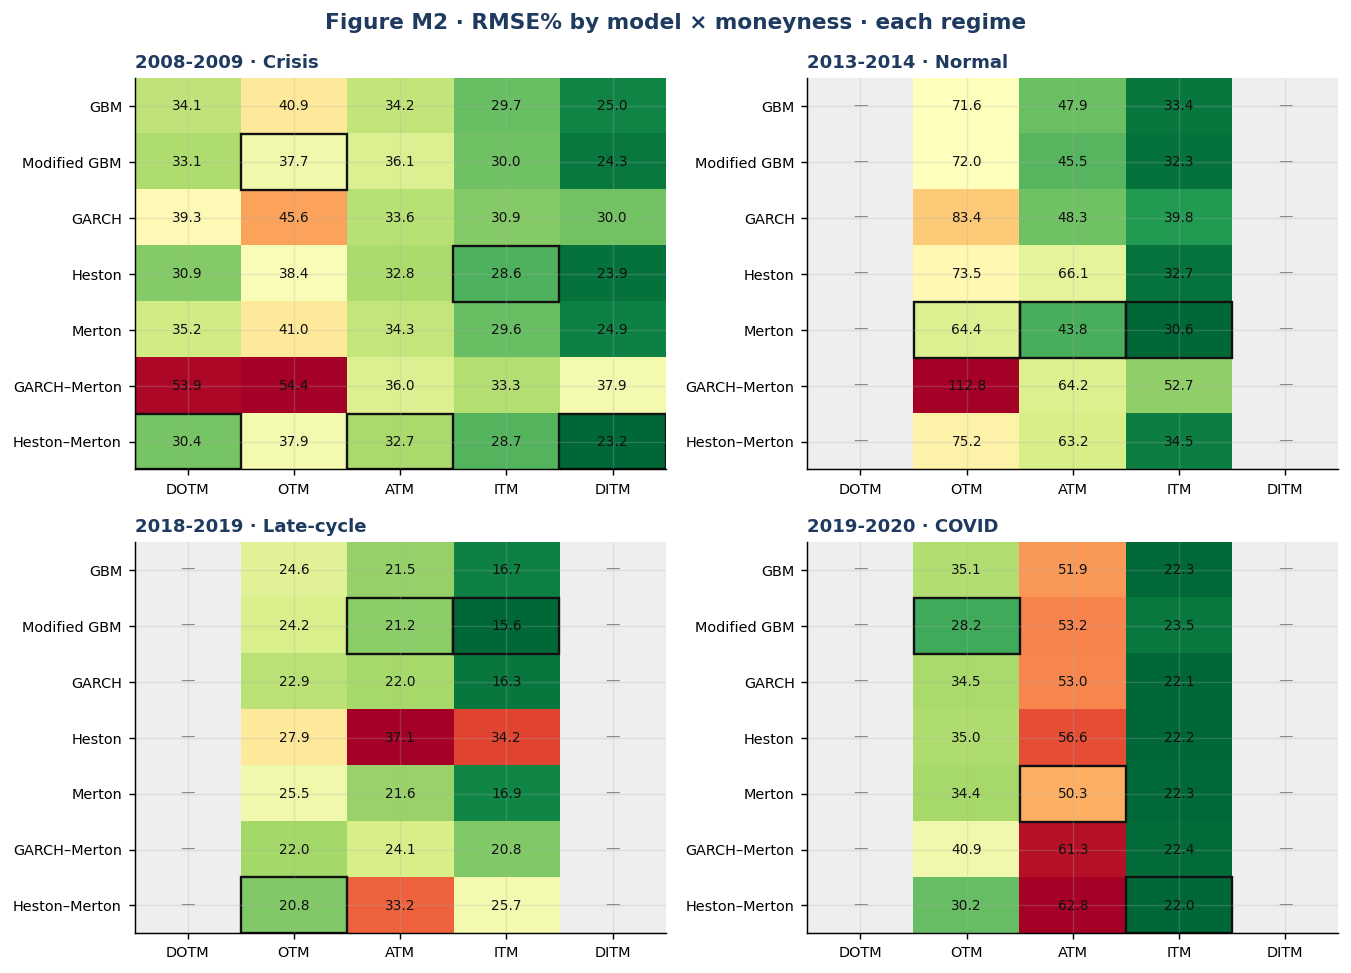

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,Heston–Merton,Modified GBM,Heston–Merton,Heston,Heston–Merton
2013-2014,—,Merton,Merton,Merton,—
2018-2019,—,Heston–Merton,Modified GBM,Modified GBM,—
2019-2020,—,Modified GBM,Merton,Heston–Merton,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,18,43,80,43,16
2013-2014,0,5,192,3,0
2018-2019,0,4,191,7,0
2019-2020,0,6,189,5,0


## 4. Findings

- DOTM (n = 18): BEST = Heston–Merton with RMSE% = 30.36, Bias% = -11.47.

- OTM (n = 58): BEST = Modified GBM with RMSE% = 40.29, Bias% = +0.62.

- ATM (n = 652): BEST = Merton with RMSE% = 39.75, Bias% = +11.64.

- ITM (n = 58): BEST = Merton with RMSE% = 27.87, Bias% = -11.59.

- DITM (n = 16): BEST = Heston–Merton with RMSE% = 23.21, Bias% = -8.28.

- Overall, the ranking does change with moneyness: DOTM → Heston–Merton, OTM → Modified GBM, ATM → Merton, ITM → Merton, DITM → Heston–Merton.

- Inside regimes, the BEST model also changes with moneyness in: 2008-2009, 2018-2019, 2019-2020.

- These comparisons use the Monday nearest-ATM sample, so ATM is the only well-populated bucket after 2009. DOTM/DITM results rest on few 2008–2009 quotes and should be read as descriptive, not as a high-powered test.


## 5. Re-run

```python
import run_v3_1p5y_10k_fixed_empirical_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V3-Models_result/results/empirical_study_1p5y_fixed_10000/contracts/`.
